# 06_07_EXO_differential_photometry  r_filter

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ccdproc, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name=version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ysfitsutilpy, ysphotutilpy, ccdproc, aplpy, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is being installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module astroquery is installed
**** module photutils is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module ccdproc is installed
**** module aplpy is installed
**** module version_information is installed
This notebook was generated at 2024-07-14 21:36:33 (KST = GMT+0900) 
0 Python     3.12.3 64bit [GCC 11.2.0]
1 IPython    8.25.0
2 OS         Linux 5.15.0 113 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.2
5 matplotlib 3.8.4
6 scipy      1.13.0
7 astropy    6.1.0
8 astroquery 0.4.7
9 photutils  1.12.0
10 ysfitsutilpy 0.2
11 ysphotutilpy 0.1.1
12 ccdproc    2.4.2
13 aplpy      2.1.0
14 version_information 1.0.4


### import modules

In [2]:
#%%
from glob import glob
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ccdproc import combine, ccd_process, CCDData

from astropy.io import fits
from astropy.wcs import WCS
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import astropy.units as u

import ysfitsutilpy as yfu
import ysphotutilpy as ypu

import _astro_utilities
import _Python_utilities
import _astro_utilities

from astropy.nddata import Cutout2D
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clip, sigma_clipped_stats
from photutils.centroids import centroid_com

from photutils.aperture import CircularAperture as CAp
from photutils.aperture import CircularAnnulus as CAn
from photutils.aperture import aperture_photometry as apphot

from astroquery.simbad import Simbad
from urllib.parse import urlencode

from scipy.optimize import curve_fit

# import matplotlib
# matplotlib.use('Agg')

plt.rcParams.update({'figure.max_open_warning': 0})

In [3]:
#%%
#######################################################
BASEDIR = Path("/mnt/Rdata/OBS_data") 
PROJECDIR = Path("/mnt/Rdata/OBS_data/2024-EXO")
TODODIR = PROJECDIR / "_-_-_2024-05_-_GSON300_STF-8300M_-_1bin"
TODODIR = PROJECDIR / "_-_-_2024-06_-_GSON300_STF-8300M_-_1bin"

# PROJECDIR = Path("/mnt/Rdata/OBS_data/2022-Asteroid")
# TODODIR = PROJECDIR / "GSON300_STF-8300M_-_1bin"
# TODODIR = PROJECDIR / "RiLA600_STX-16803_-_1bin"
# TODODIR = PROJECDIR / "RiLA600_STX-16803_-_2bin"

# PROJECDIR = Path("/mnt/Rdata/OBS_data/2023-Asteroid")
# TODODIR = PROJECDIR / "GSON300_STF-8300M_-_1bin"
# TODODIR = PROJECDIR / "RiLA600_STX-16803_-_1bin"
# TODODIR = PROJECDIR / "RiLA600_STX-16803_-_2bin"

# PROJECDIR = Path("/mnt/Rdata/OBS_data/2016-Variable")
# TODODIR = PROJECDIR / "-_-_-_2016-_-_RiLA600_STX-16803_-_2bin"

# PROJECDIR = Path("/mnt/Rdata/OBS_data/2017-Variable")
# TODODIR = PROJECDIR / "-_-_-_2017-_-_RiLA600_STX-16803_-_2bin"

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(TODODIR))
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

CALDIR = [x for x in DOINGDIRs if "CAL-BDF" in str(x)]
MASTERDIR = Path(CALDIR[0]) / _astro_utilities.master_dir
if not MASTERDIR.exists():
    os.makedirs("{}".format(str(MASTERDIR)))
    print("{} is created...".format(str(MASTERDIR)))

print ("MASTERDIR: ", format(MASTERDIR))

DOINGDIRs = sorted([x for x in DOINGDIRs if "_LIGHT_" in str(x)])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

# filter_str = '2023-12-'
# DOINGDIRs = [x for x in DOINGDIRs if filter_str in x]
# remove = 'BIAS'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'DARK'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'FLAT'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
print ("DOINGDIRs: ", DOINGDIRs)
print ("len(DOINGDIRs): ", len(DOINGDIRs))
#######################################################

DOINGDIRs:  ['/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2023_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/132AETHRA_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/322PHAEO_LIGHT_-_2016-10-19_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/3506FRENCH_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/914PALISANA_LIGHT_-_2016-10-31_-_RiLA600_STX-16803_-_2bin/', '/mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/925ALPHONSINA_LIGHT_-_2016-11-08_-_RiLA600_STX-16803_-_2bin/']
len(DOINGDIRs):  7
MASTERDIR:  /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/-_CAL-BDF_-_2023_-_RiLA600_STX-16803_-_2bin/master_files_ys
DOINGDIRs: 

In [4]:
#Returns magnitude from flux.
def mag_inst(flux, ferr):
    m_inst = -2.5 * np.log10(flux)
    merr   = 2.5/ np.log(10) * ferr / flux
    return m_inst, merr

def linf(x, a, b):
    return a + b*x

In [5]:

#####################################################################
# Observed location
LOCATION = dict(lon=127.005, lat=37.308889, elevation=101)
Suwon = location = EarthLocation(lon=127.005 * u.deg, 
                                 lat=37.308889 * u.deg, 
                                 height=101 * u.m)
observatory_code = "P64"

# Used for any `astropy.SkyCoord` object:
SKYC_KW = dict(unit=u.deg, frame='icrs')

#######################################################
# Initial guess of FWHM in pixel
FWHM_INIT = 6

# Photometry parameters
R_AP = 1.5*FWHM_INIT # Aperture radius
R_IN = 4*FWHM_INIT   # Inner radius of annulus
R_OUT = 6*FWHM_INIT  # Outer radius of annulus

Mag_Low = 11.5
Mag_High = 15

ERR_Min = 0.5
#######################################################

In [6]:
for DOINGDIR in DOINGDIRs[:] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)

DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin
DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/132AETHRA_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin
DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/322PHAEO_LIGHT_-_2016-10-19_-_RiLA600_STX-16803_-_2bin
DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/3506FRENCH_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin
DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/914PALISANA_LIGHT_-_2016-10-31_-_RiLA600_STX-16803_-_2bin
DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/925ALPHONSINA_LIGHT_-_2016-11-08_-_RiLA600_STX-16803_-_2bin


In [7]:
DOINGDIR = Path(DOINGDIRs[0])
print("DOINGDIR", DOINGDIR)

DIFFPRESULTDIR = DOINGDIR / _astro_utilities.Diff_Phot_dir
if not DIFFPRESULTDIR.exists():
    os.makedirs("{}".format(str(DIFFPRESULTDIR)))
    print("{} is created...".format(str(DIFFPRESULTDIR)))

if "RiLA600_STX-16803" in str(DOINGDIR.parts[-2]) :
    DOINGDIR = DOINGDIR / _astro_utilities.reduced_nightsky_dir
if "GSON300_STF-8300M_-_1bin" in str(DOINGDIR.parts[-2]) :
    DOINGDIR = DOINGDIR / _astro_utilities.reduced_dir

summary = yfu.make_summary(DOINGDIR/"*.fit*")
if summary is not None : 
    print("len(summary):", len(summary))
    #print("summary:", summary)
    #print(summary["file"][0])
    df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
    df_light = df_light.reset_index(drop=True)
    #print("df_light:\n{}".format(df_light))

DOINGDIR /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin
All 100 keywords (guessed from /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/REDUC_nightsky/1050META_LIGHT_B_2023-11-21-12-07-50_150sec_RiLA600_STX-16803_0c_2bin.fit) will be loaded.


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key EXTEND not found for /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-52-18_120sec_RiLA600_STX-16803_-1c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key WCSAXES not found for /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-52-18_120sec_RiLA600_STX-16803_-1c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key CTYPE1 not found for /mnt/Rdata/OBS_data/2023-

len(summary): 18


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key EXTEND not found for /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-13-07-54_120sec_RiLA600_STX-16803_-1c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key WCSAXES not found for /mnt/Rdata/OBS_data/2023-Asteroid/RiLA600_STX-16803_-_2bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_2bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-13-07-54_120sec_RiLA600_STX-16803_-1c_2bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key CTYPE1 not found for /mnt/Rdata/OBS_data/2023-

In [8]:
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    hdul = fits.open(fpath)
    ccd = yfu.load_ccd(fpath)
    flt = hdul[0].header["filter"]

In [9]:
fpath = Path(df_light["file"][0])
hdul = fits.open(fpath)
ccd = yfu.load_ccd(fpath)
flt = hdul[0].header["filter"]

SOLVE, ASTAP, LOCAL = _astro_utilities.checkPSolve(fpath)
print(SOLVE, ASTAP, LOCAL)

if SOLVE :
    wcs = WCS(hdul[0].header)
    # It is used as a rough estimate, so no need to be accurate:
    #PIX2ARCSEC = 0.62*u.arcsec
    if 'PIXSCALE' in hdul[0].header:
        PIX2ARCSEC = hdul[0].header['PIXSCALE']
    else : 
        PIX2ARCSEC = _astro_utilities.calPixScale(hdul[0].header['FOCALLEN'], 
                                        hdul[0].header['XPIXSZ'],
                                        hdul[0].header['XBINNING'])
        
    if hdul[0].header['CCDNAME'] == 'STF-8300M' :
        val_figsize = (13, 5.2)
        val_fraction = 0.035
        hdul[0].header["GAIN"] = 0.37,
        hdul[0].header["RDNOISE"] = 9.3

    if hdul[0].header['CCDNAME'] == 'STX-16803' :
        val_figsize=(12, 6.2)
        val_fraction = 0.0455
        hdul[0].header["GAIN"] = 1.27
        hdul[0].header["RDNOISE"] = 9.0    

    # It is used as a rough estimate, so no need to be accurate:
    PIX2ARCSEC = hdul[0].header["PIXSCALE"]
    rdnoise = hdul[0].header["RDNOISE"]
    gain    = hdul[0].header["GAIN"]

    # print(rdnoise, gain, PIX2ARCSEC)
    
    # D.2. Find the observation time and exposure time to set the obs time
    t_start = Time(hdul[0].header['DATE-OBS'], format='isot')
    t_expos = hdul[0].header['EXPTIME'] * u.s
    t_middle = t_start + t_expos / 2 # start time + 0.5 * exposure time
    #print(f"t_start: {t_start}, t_expos: {t_expos}, t_middle: {t_middle}")
    
    # cent_coord = yfu.center_radec(ccd_or_header=hdul[0].header, 
    #                                 center_of_image=True)

    # offset_RA = (cent_coord.ra.to(u.deg) - hdul[0].header['RA']*u.deg).to(u.arcmin)
    # offset_DEC = (cent_coord.dec.to(u.deg) - hdul[0].header['DEC']*u.deg).to(u.arcmin) 
    # altaz = AltAz(obstime=t_middle, location=Suwon)   
    # cent_aa = cent_coord.transform_to(altaz)
    # offset_AZ = (cent_aa.az.to(u.deg) - hdul[0].header['CENTAZ']*u.deg).to(u.arcmin)
    # offset_ALT = (cent_aa.alt.to(u.deg) - hdul[0].header['CENTALT']*u.deg).to(u.arcmin)




True False False
rad: 0.35239671938311534 deg


In [10]:
# Get the radius of the smallest circle which encloses all the pixels
rad = yfu.fov_radius(header=hdul[0].header, unit=u.deg)
print("rad: {}".format(rad))

cent_coord = yfu.center_radec(ccd_or_header=hdul[0].header, 
                                      center_of_image=True)
pos_sky = SkyCoord(cent_coord, unit='deg')
pos_pix = pos_sky.to_pixel(wcs=wcs)

print("pos_sky: {}".format(pos_sky))
print("pos_pix: {}".format(pos_pix))


pos_sky: <SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (12.7510878, 24.0888055)>
pos_pix: (array(1023.49999999), array(1023.49999998))


In [11]:
#%%
# Position of the telescope FOV center 
# (RA/DEC of the pixel at the center)
cent_coord = yfu.center_radec(ccd_or_header=hdul[0].header, 
                              center_of_image=True)
print("cent_coord: {}".format(cent_coord))

# Get the radius of the smallest circle which encloses all the pixels
rad = yfu.fov_radius(header=hdul[0].header, 
                     unit=u.deg)
print("rad: {}".format(rad))

cent_coord: <SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (12.7510878, 24.0888055)>
rad: 0.35239671938311534 deg


In [12]:
# # Initialize PanSTARRS1 class
# ps1 = ypu.PanSTARRS1(
#     ra=cent_coord.ra.value, 
#     dec=cent_coord.dec.value, 
#     radius=rad,
#     column_filters={"rmag":"10.0..14.5", "e_rmag":"<0.10", "nr":">5"}
# )

# # Query to the website (VizieR)
# # This is where the most of the time is spent.
# ps1.query()

# # Only select the stars within 50-pixel bezel in the FOV.
# ps1.select_xyinFOV(hdul[0].header,
#                 #bezel=50
#                 bezel=5*FWHM_INIT*PIX2ARCSEC
#                 )

# # Remove objects not suitable for differential photometry (see description below)
# ps1.drop_for_diff_phot(drop_by_Kron=True)

# # Remove redundant columns, remove objects with too few observations:
# ps1.select_filters(filter_names=['g', 'r', 'i'], n_mins=5)
# # You can try a list of ``n_mins``:
# # q.select_filters(filter_names=['g', 'r', 'i'], n_mins=[10, 3, 5])

# ps1_stars_orig = ps1.queried.copy()
# pos_stars_orig = np.array([ps1_stars_orig["x"], ps1_stars_orig["y"]]).T
# ps1_stars_orig

# fwhm = 4
# ps1.drop_star_groups(crit_separation=6*fwhm)
# ps_stars_diropped = ps1.queried.copy()  # This will be overridden: see below
# ps_stars_diropped

# df_stars = ps1.queried.to_pandas()

# PanSTARRS1 목록

PanSTARRS1 목록의 별 중에서 비교측광에 사용할 별들을 가져오자.

In [17]:
r_fov = yfu.fov_radius(ccd.header+ccd.wcs.to_header())
print(r_fov)
ps1 = ypu.PanSTARRS1(ccd.wcs.wcs.crval[0]*u.deg, ccd.wcs.wcs.crval[1]*u.deg, radius=r_fov,
                     column_filters={"rmag":f"{Mag_Low}..{Mag_High}", "e_rmag":"<0.10", "nr":">5"})

df_stars_all = ps1.query()
df_stars_all = df_stars_all.to_pandas()

isnear = ypu.organize_ps1_and_isnear(
                    ps1, 
                    # header=ccd.header+ccd.wcs.to_header(), 
                    ccd.header+ccd.wcs.to_header(), 
                    # bezel=5*FWHM_INIT*PIX2ARCSEC.value,
                    # nearby_obj_minsep=5*FWHM_INIT*PIX2ARCSEC.value,
                    bezel=5*FWHM_INIT*PIX2ARCSEC,
                    nearby_obj_minsep=5*FWHM_INIT*PIX2ARCSEC,
                    group_crit_separation=6*FWHM_INIT
                )
df_stars = ps1.queried.to_pandas()

0.35239671938311534 deg


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/queryutil.py:951: UserWarning: minsep is not Quantity. Assuming degree unit.
  warn("minsep is not Quantity. Assuming degree unit.")
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/queryutil.py:503: UserWarning: There are objects near the target!
  warn("There are objects near the target!")


110 objects remaining:  47 masked out of 157 based on [74.2554 74.2554]-pixel bezel.
 90 objects remaining:  20 masked out of 110 based on DAOGROUP with 36.000-pixel critical separation..
 87 objects remaining:   3 masked out of  90 based on f_objID ([0, 1, 2, 3, 5, 7, 8, 9, 10, 23, 24]).
 82 objects remaining:   5 masked out of  87 based on the Kron magnitude criterion.


In [18]:
# print(df_stars_all.columns)
print(df_stars.columns)

Index(['_r', 'RAJ2000', 'DEJ2000', 'objID', 'cell', 'sky', 'f_objID', 'Qual',
       'e_RAJ2000', 'e_DEJ2000', '_tab1_10', 'Ns', 'Nd', 'Ng', 'Nr', 'Ni',
       'Nz', 'Ny', 'gPSFf', 'gmag', 'e_gmag', 'gmagStd', 'o_gmag', 'b_gmag',
       'B_gmag', 'gKmag', 'e_gKmag', 'gFlags', 'rPSFf', 'rmag', 'e_rmag',
       'rmagStd', 'o_rmag', 'b_rmag', 'B_rmag', 'rKmag', 'e_rKmag', 'rFlags',
       'iPSFf', 'imag', 'e_imag', 'imagStd', 'o_imag', 'b_imag', 'B_imag',
       'iKmag', 'e_iKmag', 'iFlags', 'zPSFf', 'zmag', 'e_zmag', 'zmagStd',
       'o_zmag', 'b_zmag', 'B_zmag', 'zKmag', 'e_zKmag', 'zFlags', 'yPSFf',
       'ymag', 'e_ymag', 'ymagStd', 'o_ymag', 'b_ymag', 'B_ymag', 'yKmag',
       'e_yKmag', 'yFlags', 'x', 'y', 'grcolor', 'e_grcolor', 'Bmag', 'e_Bmag',
       'Vmag', 'e_Vmag', 'Rmag', 'e_Rmag'],
      dtype='object')


# PS1에서 얻은 별의 목록

In [19]:
df_stars["RAJ2000"].array

<NumpyExtensionArray>
[ 12.5627624, 12.51258314, 12.60753214, 12.54058709,  12.6269068, 12.61216815,
 12.54766229,  12.5732822, 12.48476122, 12.46283931, 12.65773235, 12.47790085,
 12.43253449, 12.63991549, 12.57085726, 12.45370659, 12.54893369, 12.42458096,
 12.45910738, 12.59121004,  12.5194407, 12.72918201, 12.69957382, 12.68210343,
 12.40920306, 12.51500548, 12.56589526, 12.72763918, 12.44574808, 12.42359628,
 12.67954395, 12.60492898, 12.69837158, 12.67394732, 12.47120702,  12.5177137,
 12.39775463, 12.77825345, 12.43092048,  12.4657921, 12.57000623, 12.53565132,
 12.67251221, 12.68301512, 12.56292083, 12.61099086, 12.76855639,  12.6929582,
 12.40692709, 12.55329934,  12.8056123, 12.69020318,  12.6780693, 12.78102748,
 12.41205645, 12.72433361, 12.82259377, 12.82599636, 12.66906252, 12.49663589,
 12.85437095,  12.4325179, 12.79429878, 12.45552428, 12.85077913, 12.79645171,
 12.83092597, 12.44885715, 12.89066805, 12.88493492, 12.85827047, 12.72529471,
 12.74247222, 12.88145057, 12.

In [20]:
pos_stars = np.array([df_stars["RAJ2000"].array, df_stars["DEJ2000"].array]).T
pos_stars = SkyCoord(pos_stars, **SKYC_KW).to_pixel(wcs)
pos_stars = np.transpose(pos_stars)
pos_stars

pos_stars_all = np.array([df_stars_all["RAJ2000"].array, df_stars_all["DEJ2000"].array]).T
pos_stars_all = SkyCoord(pos_stars_all, **SKYC_KW).to_pixel(wcs)
pos_stars_all = np.transpose(pos_stars_all)
pos_stars_all



array([[ 1.17348363e+03,  5.14391461e+02],
       [ 1.21243058e+03,  4.12569335e+02],
       [ 1.20388795e+03,  4.12284265e+02],
       [ 1.17602893e+03,  3.86869575e+02],
       [ 1.14016737e+03,  3.83021602e+02],
       [ 1.33035728e+03,  6.23696261e+02],
       [ 1.05507335e+03,  4.62877844e+02],
       [ 1.13705902e+03,  6.87129291e+02],
       [ 1.06891018e+03,  6.52206922e+02],
       [ 1.00447372e+03,  4.84876848e+02],
       [ 1.31811702e+03,  6.92771458e+02],
       [ 1.41504953e+03,  6.20834823e+02],
       [ 1.41349135e+03,  6.39189842e+02],
       [ 1.41402728e+03,  6.40936911e+02],
       [ 1.41425291e+03,  6.41750274e+02],
       [ 1.49417153e+03,  5.22424921e+02],
       [ 9.49070723e+02,  6.97674297e+02],
       [ 9.39893017e+02,  3.21784729e+02],
       [ 9.51797413e+02,  7.29967145e+02],
       [ 9.89156961e+02,  2.60317179e+02],
       [ 1.46439353e+03,  7.48992082e+02],
       [ 1.46042723e+03,  2.70379251e+02],
       [ 1.13667582e+03,  1.70149495e+02],
       [ 1.

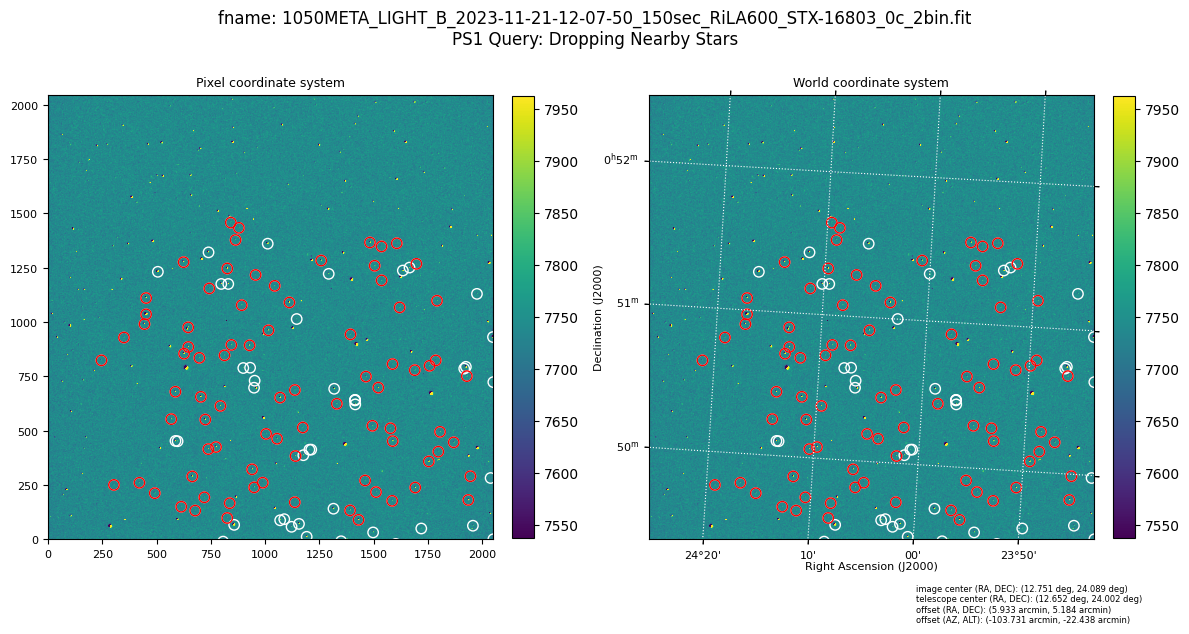

In [21]:
ap_stars = CAp(positions=pos_stars, r=R_IN)
ap_stars_all = CAp(positions=pos_stars_all, r=R_IN)

fig_set = plt.figure(figsize=val_figsize)
ax1 = plt.subplot2grid((1,2), (0,0),
                    fig=fig_set)
im1 = _astro_utilities.norm_imshow(ax1, hdul[0].data, 
                                        origin = 'lower',
                                        zscale=True)
ax1.set_title('Pixel coordinate system', fontsize=9)
ax1.tick_params(labelsize=8)
ap_stars_all.plot(ax1, color='w', lw=1)
ap_stars.plot(ax1, color='r', lw=1)
plt.colorbar(im1, ax = ax1, fraction=val_fraction, pad=0.04)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)
im2 = _astro_utilities.norm_imshow(ax2, hdul[0].data, 
                                        origin = 'lower',
                                        zscale=True)
ax2.set_title('World coordinate system', fontsize=9)
ap_stars_all.plot(ax2, color='w', lw=1)
ap_stars.plot(ax2, color='r', lw=1)

ax2.coords.grid(True, color='white', ls=':')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)', minpad=0.5, fontsize=8)
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)', minpad=0.4, fontsize=8)
ax2.coords['dec'].set_ticklabel_position('bl')
ax2.coords['ra'].set_major_formatter('hh:mm')
ax2.coords['dec'].set_major_formatter('dd:mm')
ax2.coords['ra'].display_minor_ticks(True)
ax2.coords['dec'].display_minor_ticks(True)
ax2.coords['ra'].set_minor_frequency(1)
ax2.coords['dec'].set_minor_frequency(1)
ax2.tick_params(labelsize=8)

# ax2.annotate(f"image center (RA, DEC): ({cent_coord.ra:.03f}, {cent_coord.dec:.03f})\ntelescope center (RA, DEC): ({hdul[0].header['RA']*u.deg:.03f}, {hdul[0].header['DEC']*u.deg:.03f})\noffset (RA, DEC): ({offset_RA:.03f}, {offset_DEC:.03f})\noffset (AZ, ALT): ({offset_AZ:.03f}, {offset_ALT:.03f})",
#             xy=(0, 0), xytext=(0.6, -0.1),
#             xycoords='axes fraction',
#             va='top', ha='left',
#             fontsize = 6)

plt.colorbar(im2, ax = ax2, fraction=val_fraction, pad=0.04)
plt.suptitle(f"fname: {fpath.name}\nPS1 Query: Dropping Nearby Stars")

plt.tight_layout()
plt.savefig(f"{DIFFPRESULTDIR/fpath.stem}_PS1_nearby.png")
# plt.show()
# plt.close()

In [22]:
wcs
df_stars
print(hdul[0].header["filter"])
print(len(df_stars))

df_stars = df_stars.dropna(subset=["gmag", "rmag"])
print(len(df_stars))
print(df_stars.columns)
df_stars['Rmag']

B
82
82
Index(['_r', 'RAJ2000', 'DEJ2000', 'objID', 'cell', 'sky', 'f_objID', 'Qual',
       'e_RAJ2000', 'e_DEJ2000', '_tab1_10', 'Ns', 'Nd', 'Ng', 'Nr', 'Ni',
       'Nz', 'Ny', 'gPSFf', 'gmag', 'e_gmag', 'gmagStd', 'o_gmag', 'b_gmag',
       'B_gmag', 'gKmag', 'e_gKmag', 'gFlags', 'rPSFf', 'rmag', 'e_rmag',
       'rmagStd', 'o_rmag', 'b_rmag', 'B_rmag', 'rKmag', 'e_rKmag', 'rFlags',
       'iPSFf', 'imag', 'e_imag', 'imagStd', 'o_imag', 'b_imag', 'B_imag',
       'iKmag', 'e_iKmag', 'iFlags', 'zPSFf', 'zmag', 'e_zmag', 'zmagStd',
       'o_zmag', 'b_zmag', 'B_zmag', 'zKmag', 'e_zKmag', 'zFlags', 'yPSFf',
       'ymag', 'e_ymag', 'ymagStd', 'o_ymag', 'b_ymag', 'B_ymag', 'yKmag',
       'e_yKmag', 'yFlags', 'x', 'y', 'grcolor', 'e_grcolor', 'Bmag', 'e_Bmag',
       'Vmag', 'e_Vmag', 'Rmag', 'e_Rmag'],
      dtype='object')


0     15.389788
1     14.805686
2     14.947350
3     14.840028
4     15.769892
        ...    
77    13.441026
78    13.650093
79    14.824201
80    14.975063
81    15.457182
Name: Rmag, Length: 82, dtype: float64

grizy filter와 Johnson Cousins UBVRI filter

Pan-STARRS는 g, r, i, z, y 필터를 이용해 관측을 하였다.
우리는 Johnson Cousins wideband UBVRI filter가 사용하였기 때문에 측광 값을 알맞게 변환해 줄 필요가 있다. 
Tonry et. al.(2012)의 연구결과에 `따르면 B, V, R 필터와 g, r 필터 사이에는 다음과 같은 관계가 성립한다

$B-g = 0.213 + 0.587(g-r)$   $(\pm0.034)$

$V-r = 0.006 + 0.474(g-r)$   $(\pm0.012)$

$R-r = -0.138 -0.131(g-r)$   $(\pm0.015)$

이를 변형하여 다음과 같이 적을 수 있다.

$B = 0.213 + 1.587g-0.587r$   $(\pm0.034)$

$V = 0.006 + 0.474g + 0.526r$   $(\pm0.012)$

$R = -0.138 -0.131g + 1.131r$   $(\pm0.015)$

In [23]:
# Calculate V and R, and their errors
# df_stars["Bmag"] = 0.213 + 1.587*df_stars["gmag"] - 0.587*df_stars["rmag"]
# df_stars["Vmag"] = 0.006 + 0.474*df_stars["gmag"] + 0.526*df_stars["rmag"]
# df_stars["Rmag"] = -0.138 - 0.131*df_stars["gmag"] + 1.131*df_stars["rmag"]

# df_stars["e_Vmag"] = np.sqrt(
#                     0.474**2*df_stars["gMeanPSFMagErr"]**2 
#                     + 0.526**2*df_stars["rMeanPSFMagErr"]**2 + 0.012**2
#                     )
# df_stars["e_Rmag"] = np.sqrt(
#                     0.131**2*df_stars["gMeanPSFMagErr"]**2
#                     + 1.131**2*df_stars["rMeanPSFMagErr"]**2 + 0.015**2
#                     )
# df_stars["e_gr"] = np.sqrt(df_stars["gMeanPSFMagErr"]**2 + df_stars["rMeanPSFMagErr"]**2)


# 비교 측광 수행

목록에 있는 별들의 구경 측광을 수행해서 기기등급을 구해 보자.
그리고 별들을 출력해 보자.

/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/apphot.py:326: RuntimeWarning: invalid value encountered in log10
  phot["mag"] = -2.5*np.log10(phot['source_sum']/t_exposure)
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/apphot.py:327: RuntimeWarning: divide by zero encountered in divide
  phot["merr"] = 2.5/np.log(10)*(1/snr)
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/apphot.py:326: RuntimeWarning: invalid value encountered in log10
  phot["mag"] = -2.5*np.log10(phot['source_sum']/t_exposure)
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/apphot.py:327: RuntimeWarning: divide by zero encountered in divide
  phot["merr"] = 2.5/np.log(10)*(1/snr)
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysphotutilpy/apphot.py:326: RuntimeWarning: invalid value encountered in log10
  phot["mag"] = -2.

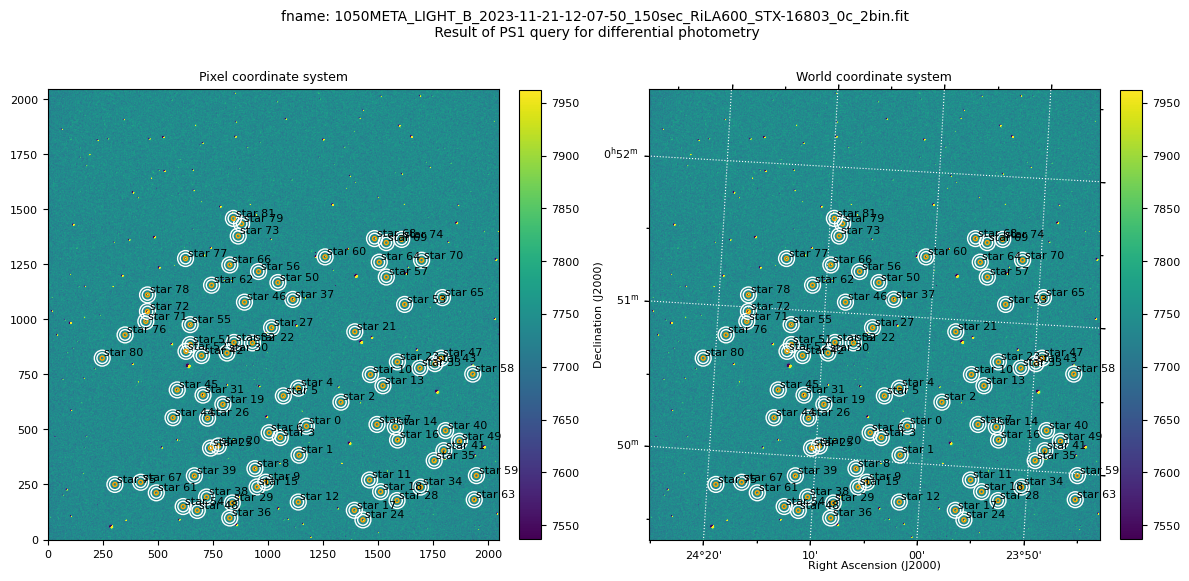

In [24]:
fig_set = plt.figure(figsize=val_figsize)

ax1 = plt.subplot2grid((1,2), (0,0),
                    fig=fig_set)
im1 = _astro_utilities.zimshow(ax1, hdul[0].data, )
ax1.set_title('Pixel coordinate system', fontsize=9)
ax1.tick_params(labelsize=8)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)
im2 = _astro_utilities.zimshow(ax2, hdul[0].data, )

_phot_stars = []

for i, row in df_stars.iterrows():
    pos_star = SkyCoord(row["RAJ2000"], row["DEJ2000"], 
                        **SKYC_KW).to_pixel(wcs)
    ap = CAp([pos_star[0], pos_star[1]], 
             r=R_AP)
    an = CAn([pos_star[0], pos_star[1]], 
             r_in=R_IN, r_out=R_OUT)
    _phot_star = ypu.apphot_annulus(hdul[0].data, 
                                    ap, an, 
                                    error=yfu.errormap(hdul[0].data))
    _phot_star[f"{flt}mag"] = row[f"{flt}mag"]
    _phot_star[f"e_{flt}mag"] = row[f"e_{flt}mag"]
    _phot_star["gmag"] = row["gmag"]
    _phot_star["e_gmag"] = row["e_gmag"]
    _phot_star["rmag"] = row["rmag"]
    _phot_star["e_rmag"] = row["e_rmag"]
    _phot_star["grcolor"] = row["grcolor"]
    _phot_star["e_grcolor"] = row["e_grcolor"]
    _phot_star["id"] = i
    _phot_star["objID"] = int(row["objID"])
    _phot_stars.append(_phot_star)
    ax1.text(pos_star[0]+10, pos_star[1]+10, f"star {i}", fontsize=8)
    ap.plot(ax1, color="orange")
    an.plot(ax1, color="w")
    ax2.text(pos_star[0]+10, pos_star[1]+10, f"star {i}", fontsize=8)
    ap.plot(ax2, color="orange")
    an.plot(ax2, color="w")

ax2.set_title('World coordinate system', fontsize=9)
ax2.coords.grid(True, color='white', ls=':')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)', minpad=0.5, fontsize=8)
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)', minpad=0.4, fontsize=8)
ax2.coords['dec'].set_ticklabel_position('bl')
ax2.coords['ra'].set_major_formatter('hh:mm')
ax2.coords['dec'].set_major_formatter('dd:mm')
ax2.coords['ra'].display_minor_ticks(True)
ax2.coords['dec'].display_minor_ticks(True)
ax2.coords['ra'].set_minor_frequency(2)
ax2.coords['dec'].set_minor_frequency(2)
ax2.tick_params(labelsize=8)

cbar1 = plt.colorbar(im1, ax = ax1, fraction=val_fraction, pad=0.04)
cbar2 = plt.colorbar(im2, ax = ax2, fraction=val_fraction, pad=0.04, )
cbar1.ax.tick_params(labelsize=8)
cbar2.ax.tick_params(labelsize=8)

plt.suptitle(f"fname: {fpath.name}\n Result of PS1 query for differential photometry", fontsize=10,)

plt.tight_layout()
plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_PS1_query.png")

# plt.show()
# plt.close()

In [25]:
_phot_star

,id,xcenter,ycenter,aperture_sum,aperture_sum_err,msky,ssky,nsky,nrej,aparea,...,nbadpix,Bmag,e_Bmag,gmag,e_gmag,rmag,e_rmag,grcolor,e_grcolor,objID
0,81,842.097214,1457.970659,1.972314e+06,1404.391053,7738.276569,66.865347,2213,47,254.469005,...,0,16.472017,0.034035,16.0322,0.0016,15.6458,0.0021,0.3864,0.00264,136990129111823008


In [26]:
phot_stars = pd.concat(_phot_stars)
# phot_stars = phot_stars.loc[phot_stars["objID"] != 110823405221754720].copy()  # star 15
# SEE THE LAST CELL IN THIS FILE FOR DESCRIPTION
print(len(phot_stars))
print(phot_stars.columns)
print(phot_stars)

82
Index(['id', 'xcenter', 'ycenter', 'aperture_sum', 'aperture_sum_err', 'msky',
       'ssky', 'nsky', 'nrej', 'aparea', 'source_sum', 'source_sum_err', 'mag',
       'merr', 'snr', 'bad', 'nbadpix', 'Bmag', 'e_Bmag', 'gmag', 'e_gmag',
       'rmag', 'e_rmag', 'grcolor', 'e_grcolor', 'objID'],
      dtype='object')
    id      xcenter      ycenter  aperture_sum  aperture_sum_err         msky  \
0    0  1173.483632   514.391461  1.971556e+06       1404.120953  7738.870975   
0    1  1140.167369   383.021602  1.971425e+06       1404.074574  7741.785051   
0    2  1330.357277   623.696261  1.970917e+06       1403.893690  7738.307766   
0    3  1055.073351   462.877844  1.970807e+06       1403.854484  7740.165655   
0    4  1137.059019   687.129291  1.972043e+06       1404.294602  7741.219817   
..  ..          ...          ...           ...               ...          ...   
0   77   624.667413  1275.846720  1.975461e+06       1405.511046  7740.574513   
0   78   452.086852  1110.658181 

In [27]:
print(phot_stars.columns)
phot_stars_na = phot_stars.dropna()
print(len(phot_stars_na))

phot_stars_na = phot_stars[phot_stars["merr"] < ERR_Min]
print(len(phot_stars_na))
print(phot_stars_na)

Index(['id', 'xcenter', 'ycenter', 'aperture_sum', 'aperture_sum_err', 'msky',
       'ssky', 'nsky', 'nrej', 'aparea', 'source_sum', 'source_sum_err', 'mag',
       'merr', 'snr', 'bad', 'nbadpix', 'Bmag', 'e_Bmag', 'gmag', 'e_gmag',
       'rmag', 'e_rmag', 'grcolor', 'e_grcolor', 'objID'],
      dtype='object')
67
16
   id      xcenter      ycenter  aperture_sum  aperture_sum_err         msky  \
0   5  1068.910178   652.206923  1.975286e+06       1405.448590  7736.925739   
0  16  1587.412567   451.780502  1.974656e+06       1405.224361  7739.823065   
0  20   773.897720   424.557966  1.973804e+06       1404.921308  7740.554190   
0  22   928.671529   892.760682  1.973531e+06       1404.824365  7737.504547   
0  24  1430.220411    89.062513  1.974676e+06       1405.231807  7737.657372   
0  27  1015.484598   961.862049  1.974078e+06       1405.018767  7740.475126   
0  34  1691.374652   237.955810  1.974821e+06       1405.283106  7742.568073   
0  35  1753.847112   358.183719  1.974

$M_f=m_f+(\text { effect of atmosphere })+(\text { effect of CCD }) \approx m_f-k_f^{\prime} X-k_f^{\prime \prime} X C+z_f+k_f C$

where
- $f$ : The filter ( $\mathrm{V}, \mathrm{B}, \mathrm{g}$ ', etc). In our case, $\mathrm{V}$.
- X: airmass (the simplest approximation is the secant of zenith angle, sec $Z$ ).
- $M_f$ : The standard apparent magnitude (or the true apparent magnitude) at filter $f$.
- $m_f$ : The instrumental magnitude ( $m_f=-2.5 \lg N$ ).
- $C$ : The true color index, e.g., $B-V$ or $r^{\prime}-i^{\prime}$. (Not necessarily include filter $f$, but it is better that the wavelength ranges of the selected two filters "contain" the range of $f$ for interpolation purpose. Also in many classical literatures, you will see the $C$ in this equation is the observed color, not the true color. This is just a matter of preference.)
- $k_f^{\prime}$ : The first order extinction coefficient at filter $f$.
- $k_f^{\prime \prime}$ : The second order extinction coefficient at filter $f$.
- $z_f$ : The zero point at filter $f$.
- $k_f$ : The system transform coefficient at filter $f$.
- Note: In the lecture note, lower- and upper-cased letters are used for the instrumental and true magnitudes, respectively (For example, $v, b, m_{g^{\prime}}$ are instrumental magnitudes of an object and $V, B$, and $M_{g^{\prime}}$ are true appparent magnitudes of it.).

In the simplest case,
$$  v=V+Z $$

for the zero point $Z$ (i.e., assume all the terms are constant). In our case, we calculate the zero point in this single image, and since the airmass $X$ is identical for every object in the FoV, this is quite a reasonalble guess. The color-term will be shown to be negligible (see below).

Note that putting $v\left(=m_f\right)$ to the LHS is to put it in the ordinate in the fitting process below.


{note}
The [weighted mean with variance weighting](https://en.wikipedia.org/wiki/Weighted_arithmetic_mean#Variance_weights) of $x_i$ is given as

$$ 
\bar{x} = \frac{\sum_i x_i / \sigma_i^2}{\sum_i 1 / \sigma_i^2} 
\quad;\quad
\sigma_{\bar{x}} = \frac{1}{\sqrt{\sum_{i=1}^{N} 1 / \sigma_i^2} } ~.
$$

In the simplest formalism, $Z=v-V$ can be calculated for multiple stars. The $Z$ and $d Z$ values can be calculated from this weighed mean, using $Z_i$ for the $\mathrm{i}$-th stars will be the zero point value. The error-bar of each can be roughly estimated as $d Z_i=\sqrt{d v^2+d V^2}$. However, if the error-bar of each star (i.e., the dv and $\mathrm{dV}$ values) are not correctly measured (many times it is the case), it is sometimes better to use simple sample standard deviation: np.std(Z_i, ddof $=1$ ). Normally many people use whichever is larger:
$$
d Z=\max \left(\frac{1}{\sqrt{\sum 1 / d Z_i^2}}, \frac{\text { np. std } \left.\left(\mathrm{Z}_{\mathrm{i}}, \text { ddof }=1\right)\right)}{\sqrt{N}}\right)
$$

In [28]:
# from scipy.optimize import curve_fit

# def linf(x, a, b):
#     return a + b*x

# mcat, dmcat = phot["V"], phot["dV"]
# mobs, dmobs = phot["mag"], phot["merr"]
# color = phot["g"] - phot["r"]
# dmtot = np.sqrt(dmcat**2 + dmobs**2)

# # === Calculate zero point and errors
# zeropt = np.average(mobs - mcat, weights=1/dmtot**2)
# dzeropt = np.max([1/np.sqrt(np.sum(1/dmtot**2)), np.std(mobs - mcat, ddof=1)/np.sqrt(len(mcat))])
# dmtot2 = np.sqrt(dmtot**2 + dzeropt**2)

# # === Find fitting lines
# # Search for the usage of scipy.optimize.curve_fit.
# poptm, _ = curve_fit(linf, mcat, mobs, sigma=dmobs, absolute_sigma=True)
# poptc, _ = curve_fit(linf, color, mobs-mcat, sigma=dmtot2, absolute_sigma=True)

In [29]:
merr_total1 = np.sqrt((phot_stars_na["merr"])**2 + (phot_stars_na[f"e_{flt}mag"])**2)

# === Calculate zero point and errors
_xx = np.linspace(Mag_Low, Mag_High)
zeropt_med = np.median(phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"])
zeropt_avg = np.average(phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], 
                        weights=1/merr_total1**2)
dzeropt = np.max([1/np.sqrt(np.sum(1/(merr_total1)**2)), 
                  np.std((phot_stars_na[f"e_{flt}mag"] - phot_stars_na["merr"]), ddof=1)/np.sqrt(len(phot_stars_na[f"{flt}mag"]))])
merr_total2 = np.sqrt(np.sqrt(merr_total1**2 + dzeropt**2))

# === Find fitting lines
# Search for the usage of scipy.optimize.curve_fit.
poptm, _ = curve_fit(linf, phot_stars_na[f"{flt}mag"], 
                     phot_stars_na["mag"],
                     sigma= phot_stars_na["merr"], absolute_sigma=True)
poptc, _ = curve_fit(linf, phot_stars_na["grcolor"], 
                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], 
                     sigma=merr_total2, absolute_sigma=True)

In [30]:
merr_total1
merr_total2
poptm
poptc

array([-24.56195784,  -0.12741129])

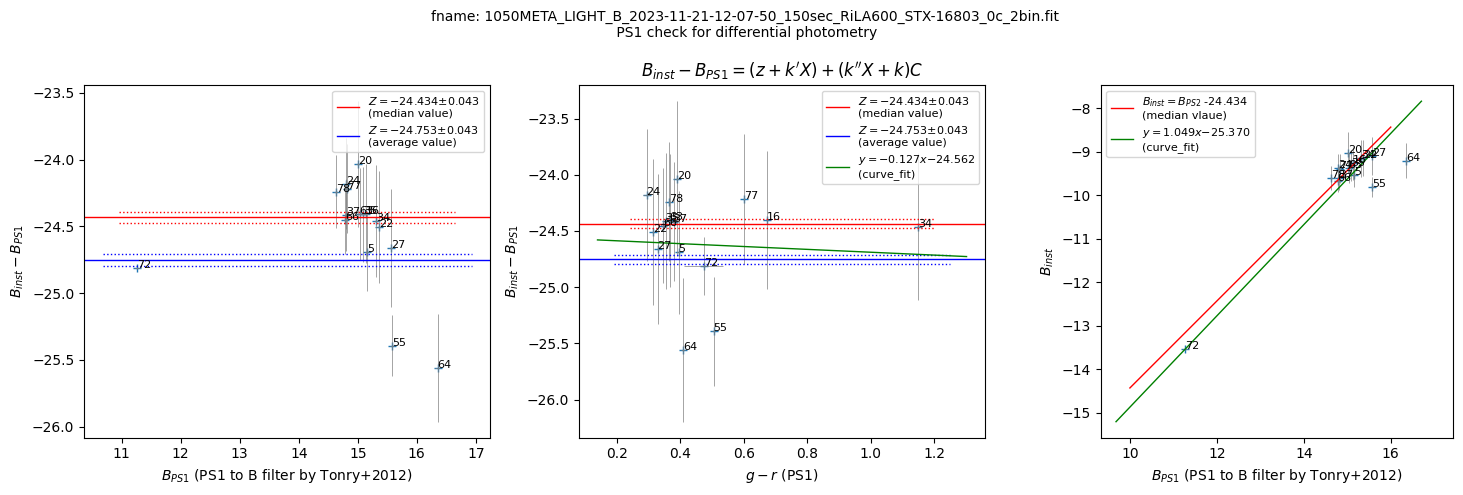

In [53]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False, gridspec_kw=None)
# errkw = dict(marker="", ls="", ecolor="gray", elinewidth=0.5)

# axs[0].plot(phot_stars_na[f"{flt}mag"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
# axs[0].errorbar(phot_stars_na[f"{flt}mag"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], 
#             xerr=phot_stars_na[f"e_{flt}mag"], 
#             yerr=phot_stars_na["merr"], 
#             **errkw)

# axs[1].plot(phot_stars_na["grcolor"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
# axs[1].errorbar(phot_stars_na["grcolor"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
#             xerr=phot_stars_na[f"e_grcolor"], 
#             yerr=merr_total2, 
#             **errkw)

# axs[2].plot(phot_stars_na[f"{flt}mag"], phot_stars_na["mag"], '+')
# axs[2].errorbar(phot_stars_na[f"{flt}mag"], 
#             phot_stars_na["mag"], 
#             xerr=phot_stars_na[f"e_{flt}mag"], 
#             yerr=phot_stars_na["merr"], 
#             **errkw)
# axs[2].plot(_xx, _xx + zeropt_med,
#             label=f"${{{flt}}}_{{inst}} = {{{flt}}}_{{PS2}}$ {zeropt_med:+.03f}\n(median vlaue)",
#             color="r", lw=1, ls="-"
#             )

# for _, row in phot_stars_na.iterrows():
#     axs[0].text(row[f"{flt}mag"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[1].text(row["grcolor"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[2].text(row[f"{flt}mag"], row["mag"], int(row["id"]), fontsize=8)

# axs[0].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
# axs[0].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#               *np.array(axs[0].get_xlim()), 
#               color="r", lw=1, ls=":" ) 
# axs[0].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
# axs[0].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#               *np.array(axs[0].get_xlim()), 
#               color="b", lw=1, ls=":" ) 
# axs[1].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
# axs[1].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#               *np.array(axs[1].get_xlim()), 
#               color="r", lw=1, ls=":" ) 
# axs[1].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
# axs[1].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#               *np.array(axs[1].get_xlim()), 
#               color="b", lw=1, ls=":" ) 
# axs[1].plot(np.array(axs[1].get_xlim()), 
#             linf(np.array(axs[1].get_xlim()), *poptc), 
#             "g-", lw=1, label=f"$y = {{{poptc[1]:+.3f}}}x {{{poptc[0]:+.3f}}}$\n(curve_fit)", 
#             # *axs[1].get_xlim(),
#             )
# axs[2].plot(np.array(axs[2].get_xlim()), 
#             linf(np.array(axs[2].get_xlim()), *poptm),
#             "g-", lw=1, 
#             label=f"$y = {{{poptm[1]:.3f}}}x {{{poptm[0]:+.3f}}}$\n(curve_fit)", 
#             # *axs[2].get_xlim(),
#             )

# axs[0].set(
#     xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
#     ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$"
# )
# axs[1].set(
#     title=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}} = (z + k'X) + (k''X + k)C$",
#     xlabel="$g - r$ (PS1)",
#     ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$"
# )
# axs[2].set(
#     xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
#     ylabel =f"${{{flt}}}_{{inst}}$",
# )

# axs[2].axis('square')

# axs[0].legend(fontsize=8, loc='best')
# axs[1].legend(fontsize=8, loc='best')
# axs[2].legend(fontsize=8, loc='best')

# plt.suptitle(f"fname: {fpath.name}\n PS1 check for differential photometry", fontsize=10,)

# plt.tight_layout()
# plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization.png")

# # plt.show()
# # plt.close()

## 그래프 추가중

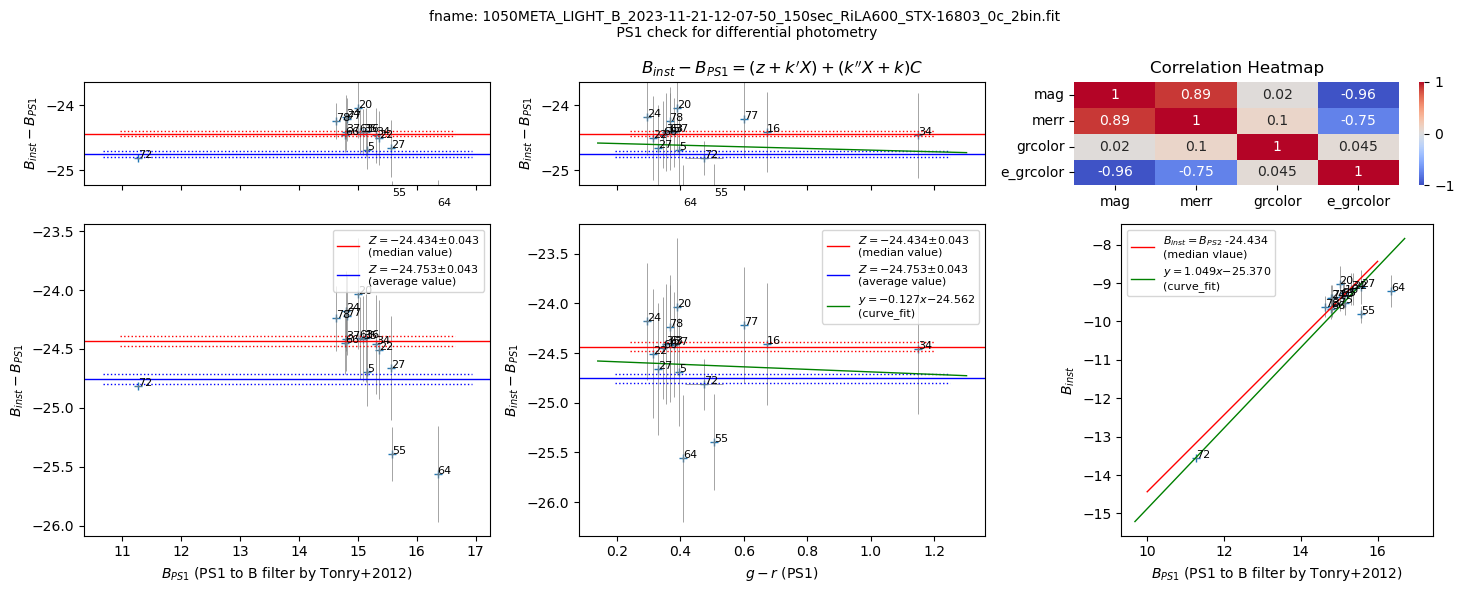

In [163]:
# fig, axs = plt.subplots(2, 3, figsize=(15, 6), sharex=False, sharey=False, 
#                         gridspec_kw={'height_ratios': [1, 3]})
# errkw = dict(marker="", ls="", ecolor="gray", elinewidth=0.5)

# # 상단 행 (원래 하단 행이었던 것)
# for i in range(3):
#     if i == 0:
#         axs[0, i].plot(phot_stars_na[f"{flt}mag"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
#         axs[0, i].errorbar(phot_stars_na[f"{flt}mag"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], 
#                     xerr=phot_stars_na[f"e_{flt}mag"], 
#                     yerr=phot_stars_na["merr"], 
#                     **errkw)
#         axs[0, i].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
#         axs[0, i].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#                     *np.array(axs[0, i].get_xlim()), 
#                     color="r", lw=1, ls=":" )
#         axs[0, i].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
#         axs[0, i].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#                     *np.array(axs[0, i].get_xlim()), 
#                     color="b", lw=1, ls=":" )
#         axs[0, i].set(
#             ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$",
#             ylim = (zeropt_med-0.8, zeropt_med+0.8),
#             )

#     elif i == 1:
#         axs[0, i].plot(phot_stars_na["grcolor"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
#         axs[0, i].errorbar(phot_stars_na["grcolor"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
#                     xerr=phot_stars_na[f"e_grcolor"], 
#                     yerr=merr_total2, 
#                     **errkw)
#         axs[0, i].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
#         axs[0, i].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#                     *np.array(axs[0, i].get_xlim()), 
#                     color="r", lw=1, ls=":" )
#         axs[0, i].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
#         axs[0, i].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#                     *np.array(axs[0, i].get_xlim()), 
#                     color="b", lw=1, ls=":" )
#         axs[0, i].plot(np.array(axs[0, i].get_xlim()), 
#             linf(np.array(axs[0, i].get_xlim()), *poptc), 
#             "g-", lw=1, label=f"$y = {{{poptc[1]:+.3f}}}x {{{poptc[0]:+.3f}}}$\n(curve_fit)", 
#             )
#         axs[0, i].set(
#                     title=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}} = (z + k'X) + (k''X + k)C$",
#                     ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$",
#                     ylim = (zeropt_med-0.8, zeropt_med+0.8),
#                 )
#     elif i == 2:
#         data =  phot_stars_na[["mag", "merr", "grcolor", "e_grcolor"]]
#         corr = data.corr()
#         axs[0, i] = sns.heatmap(corr, annot=True, cmap='coolwarm', 
#                      vmin=-1, vmax=1, center=0, ax=axs[0, i])
#         axs[0, i].set(title='Correlation Heatmap')

# # 하단 행 (원래 상단 행이었던 것)
# for i in range(3):
#     if i == 0:
#         axs[1, i].plot(phot_stars_na[f"{flt}mag"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
#         axs[1, i].errorbar(phot_stars_na[f"{flt}mag"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], 
#                     xerr=phot_stars_na[f"e_{flt}mag"], 
#                     yerr=phot_stars_na["merr"], 
#                     **errkw)
#         axs[1, i].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
#         axs[1, i].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#                     *np.array(axs[1, i].get_xlim()), 
#                     color="r", lw=1, ls=":" )
#         axs[1, i].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
#         axs[1, i].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#                     *np.array(axs[1, i].get_xlim()), 
#                     color="b", lw=1, ls=":" )
#         axs[1, i].set(
#             xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
#             ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$"
#         )
#         axs[1, i].legend(fontsize=8, loc='best')
#     elif i == 1:
#         axs[1, i].plot(phot_stars_na["grcolor"], 
#             phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
#         axs[1, i].errorbar(phot_stars_na["grcolor"], 
#                     phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
#                     xerr=phot_stars_na[f"e_grcolor"], 
#                     yerr=merr_total2, 
#                     **errkw)
#         axs[1, i].axhline(zeropt_med, color="r", lw=1,
#                label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
#         axs[1, i].hlines([dzeropt+zeropt_med, -dzeropt+zeropt_med], 
#                     *np.array(axs[1, i].get_xlim()), 
#                     color="r", lw=1, ls=":" )
#         axs[1, i].axhline(zeropt_avg, color="b", lw=1,
#                label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
#         axs[1, i].hlines([dzeropt+zeropt_avg, -dzeropt+zeropt_avg], 
#                     *np.array(axs[1, i].get_xlim()), 
#                     color="b", lw=1, ls=":" )
#         axs[1, i].plot(np.array(axs[1, i].get_xlim()), 
#             linf(np.array(axs[1, i].get_xlim()), *poptc), 
#             "g-", lw=1, label=f"$y = {{{poptc[1]:+.3f}}}x {{{poptc[0]:+.3f}}}$\n(curve_fit)", 
#             )
#         axs[1, i].set(
#                     xlabel="$g - r$ (PS1)",
#                     ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$"
#                 )
#         axs[1, i].legend(fontsize=8, loc='best')
#     elif i == 2:
#         axs[1, i].plot(phot_stars_na[f"{flt}mag"], phot_stars_na["mag"], '+')
#         axs[1, i].errorbar(phot_stars_na[f"{flt}mag"], 
#                     phot_stars_na["mag"], 
#                     xerr=phot_stars_na[f"e_{flt}mag"], 
#                     yerr=phot_stars_na["merr"], 
#                     **errkw)
#         axs[1, i].plot(_xx, _xx + zeropt_med,
#                     label=f"${{{flt}}}_{{inst}} = {{{flt}}}_{{PS2}}$ {zeropt_med:+.03f}\n(median vlaue)",
#                     color="r", lw=1, ls="-"
#                     )
#         axs[1, i].plot(np.array(axs[1, i].get_xlim()), 
#             linf(np.array(axs[1, i].get_xlim()), *poptm),
#             "g-", lw=1, 
#             label=f"$y = {{{poptm[1]:.3f}}}x {{{poptm[0]:+.3f}}}$\n(curve_fit)", 
#             )
#         axs[1, i].set(
#                     xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
#                     ylabel =f"${{{flt}}}_{{inst}}$",
#                 )
#         axs[1, i].legend(fontsize=8, loc='best')
#         axs[1, i].axis('square')

# # ID 텍스트 추가
# for _, row in phot_stars_na.iterrows():
#     axs[1, 0].text(row[f"{flt}mag"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[1, 1].text(row["grcolor"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[1, 2].text(row[f"{flt}mag"], row["mag"], int(row["id"]), fontsize=8)
#     axs[0, 0].text(row[f"{flt}mag"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[0, 1].text(row["grcolor"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)

# # x축 레이블 숨기기 (상단 행)
# axs[0, 0].tick_params(labelbottom=False)
# axs[0, 1].tick_params(labelbottom=False)

# plt.suptitle(f"fname: {fpath.name}\n PS1 check for differential photometry", fontsize=10)
# plt.tight_layout()
# plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization_extended.png")

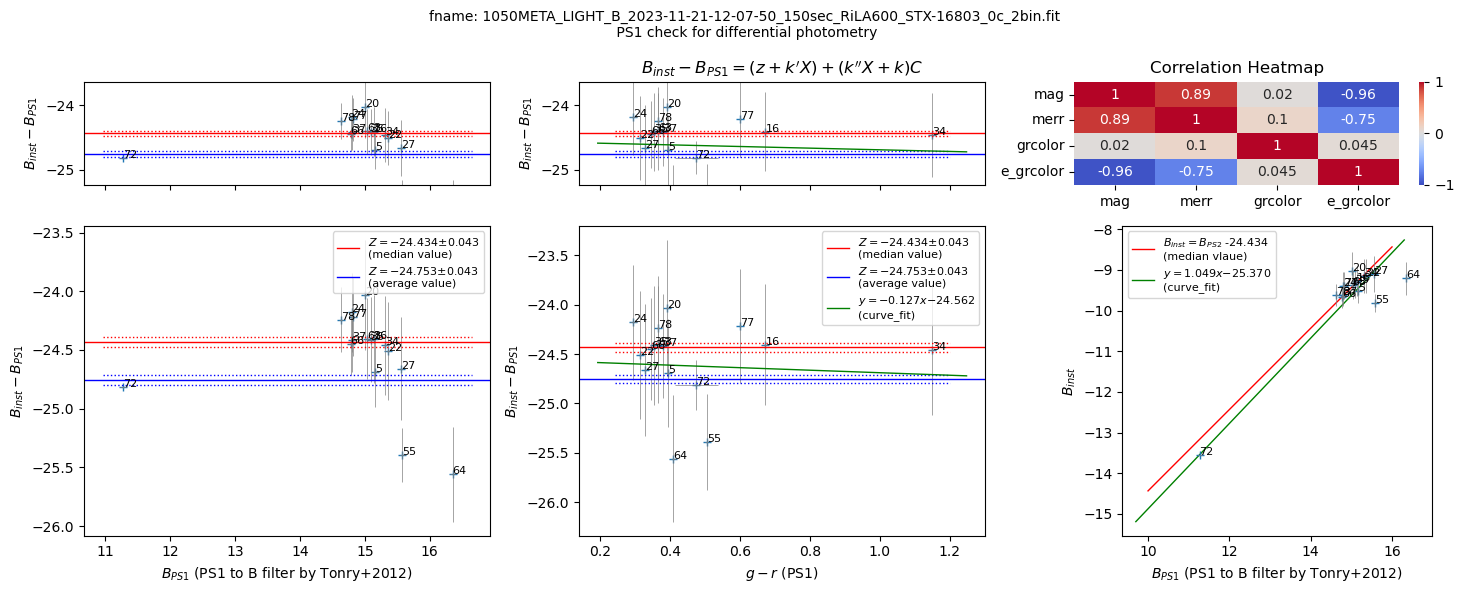

In [171]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6), sharex=False, sharey=False, 
                        gridspec_kw={'height_ratios': [1, 3]})
errkw = dict(marker="", ls="", ecolor="gray", elinewidth=0.5)

def plot_common(ax, x, y, xerr, yerr, title="", xlabel="", ylabel="", ylim=None):
    ax.plot(x, y, '+')
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, **errkw)
    ax.axhline(zeropt_med, color="r", lw=1, label=f"$Z = {{{zeropt_med:.3f}}} ± {{{dzeropt:.3f}}}$\n(median value)")
    ax.axhline(zeropt_avg, color="b", lw=1, label=f"$Z = {{{zeropt_avg:.3f}}} ± {{{dzeropt:.3f}}}$\n(average value)")
    ax.hlines([zeropt_med + dzeropt, zeropt_med - dzeropt, zeropt_avg + dzeropt, zeropt_avg - dzeropt], 
              *ax.get_xlim(), color=["r","r","b","b"], lw=1, ls=":")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel, ylim=ylim)
    # ax.legend(fontsize=8, loc='best')

# 상단 행
plot_common(axs[0, 0], phot_stars_na[f"{flt}mag"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
            phot_stars_na[f"e_{flt}mag"], phot_stars_na["merr"],
            ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$",
            ylim=(zeropt_med-0.8, zeropt_med+0.8))

plot_common(axs[0, 1], phot_stars_na["grcolor"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
            phot_stars_na[f"e_grcolor"], merr_total2,
            title=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}} = (z + k'X) + (k''X + k)C$",
            ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$",
            ylim=(zeropt_med-0.8, zeropt_med+0.8))
axs[0, 1].plot(axs[0, 1].get_xlim(), linf(np.array(axs[0, 1].get_xlim()), *poptc), 
               "g-", lw=1, label=f"$y = {{{poptc[1]:+.3f}}}x {{{poptc[0]:+.3f}}}$\n(curve_fit)")
# axs[0, 1].legend(fontsize=8, loc='best')

data = phot_stars_na[["mag", "merr", "grcolor", "e_grcolor"]]
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=axs[0, 2])
axs[0, 2].set(title='Correlation Heatmap')

# 하단 행
plot_common(axs[1, 0], phot_stars_na[f"{flt}mag"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
            phot_stars_na[f"e_{flt}mag"], phot_stars_na["merr"],
            xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
            ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$")

plot_common(axs[1, 1], phot_stars_na["grcolor"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"],
            phot_stars_na[f"e_grcolor"], merr_total2,
            xlabel="$g - r$ (PS1)",
            ylabel=f"${{{flt}}}_{{inst}} - {{{flt}}}_{{PS1}}$")
axs[1, 1].plot(axs[1, 1].get_xlim(), linf(np.array(axs[1, 1].get_xlim()), *poptc), 
               "g-", lw=1, label=f"$y = {{{poptc[1]:+.3f}}}x {{{poptc[0]:+.3f}}}$\n(curve_fit)")
axs[1, 0].legend(fontsize=8, loc='best')
axs[1, 1].legend(fontsize=8, loc='best')

# plot_common(axs[1, 2], phot_stars_na[f"{flt}mag"], phot_stars_na["mag"],
#             phot_stars_na[f"e_{flt}mag"], phot_stars_na["merr"],
#             xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
#             ylabel=f"${{{flt}}}_{{inst}}$")
axs[1, 2].plot(_xx, _xx + zeropt_med,
            label=f"${{{flt}}}_{{inst}} = {{{flt}}}_{{PS2}}$ {zeropt_med:+.03f}\n(median vlaue)",
            color="r", lw=1, ls="-")
axs[1, 2].plot(axs[1, 2].get_xlim(), linf(np.array(axs[1, 2].get_xlim()), *poptm),
            "g-", lw=1, label=f"$y = {{{poptm[1]:.3f}}}x {{{poptm[0]:+.3f}}}$\n(curve_fit)")
axs[1, 2].plot(phot_stars_na[f"{flt}mag"], phot_stars_na["mag"], '+')
axs[1, 2].errorbar(phot_stars_na[f"{flt}mag"], 
            phot_stars_na["mag"], 
            xerr=phot_stars_na[f"e_{flt}mag"], 
            yerr=phot_stars_na["merr"], 
            **errkw)
axs[1, 2].set(
            xlabel=f"${{{flt}}}_{{PS1}}$ (PS1 to {flt} filter by Tonry+2012)",
            ylabel =f"${{{flt}}}_{{inst}}$",
        )
axs[1, 2].legend(fontsize=8, loc='best')
axs[1, 2].axis('square')

# ID 텍스트 추가
for _, row in phot_stars_na.iterrows():
    for i in range(2):
        for j in range(2):
            axs[i, j].text(row[f"{flt}mag" if j == 0 else "grcolor"], 
                           row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8, clip_on=True)
    axs[1, 2].text(row[f"{flt}mag"], row["mag"], int(row["id"]), fontsize=8, clip_on=True)

# x축 레이블 숨기기 (상단 행)
for ax in axs[0, :2]:
    ax.tick_params(labelbottom=False)

plt.suptitle(f"fname: {fpath.name}\n PS1 check for differential photometry", fontsize=10)
plt.tight_layout()
plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization_extended.png")

In [32]:
phot_stars_na.columns

Index(['id', 'xcenter', 'ycenter', 'aperture_sum', 'aperture_sum_err', 'msky',
       'ssky', 'nsky', 'nrej', 'aparea', 'source_sum', 'source_sum_err', 'mag',
       'merr', 'snr', 'bad', 'nbadpix', 'Bmag', 'e_Bmag', 'gmag', 'e_gmag',
       'rmag', 'e_rmag', 'grcolor', 'e_grcolor', 'objID'],
      dtype='object')

In [33]:
# # === Plot
# # --- Set some useful things
# errkw = dict(marker="", ls="", ecolor="gray", elinewidth=0.5)

# # --- Main plot with error bars and fitting lines
# fig, axs = plt.subplot_mosaic("mc\nmc\nrc", figsize=(10, 5))
# # m = magnitudes, c=colors, r=residuals
# axs["m"].plot(mcat, mobs, "k.", ms=5)
# axs["m"].errorbar(mcat, mobs, xerr=dmcat, yerr=dmobs, **errkw)
# axs["r"].plot(mcat, mobs - mcat - zeropt, "k.", ms=5)
# axs["r"].errorbar(mcat, mobs - mcat - zeropt, xerr=dmcat, yerr=dmtot2, **errkw)
# axs["c"].plot(color, mobs - mcat, "k.", ms=5)
# # axs["c"].errorbar(color, mobs - mcat, xerr=phot["dgr"], yerr=dmtot2, **errkw)

# mm = np.array(axs["m"].get_xlim())
# cc = np.array(axs["c"].get_xlim())

# # Fitted lines
# axs["m"].plot(mm, zeropt + mm, "r-", lw=1, label=f"Z = {zeropt:+.3f} (fix slope)")
# axs["m"].plot(mm, linf(mm, *poptm), "b:", lw=1, label=f"y = {poptm[1]:.3f}x {poptm[0]:+.3f}", *axs["m"].get_xlim())
# axs["c"].plot(cc, linf(cc, *poptc), "r-", lw=1, label=f"y = {poptc[1]:+.3f}x {poptc[0]:+.3f}", *axs["c"].get_xlim())

# # --- Some codes to make the plot prettier
# # axs["m"].axhline(m_targ, color="k", lw=1, label=f"Target v = {m_targ:.3f} ± {dm_targ:.3f}")
# # axs["m"].hlines([m_targ+dm_targ, m_targ-dm_targ], *axs["m"].get_xlim(), color="k", lw=1, ls=":")

# for i, row in phot_stars_na.iterrows():
#     axs["m"].text(row[f"{flt}mag"], row["mag"], i, fontsize=8)
#     axs["r"].text(row[f"{flt}mag"], row["mag"] - row[f"{flt}mag"] - zeropt, i, fontsize=8)
#     axs["c"].text(row["gmag"] - row["rmag"], row["mag"] - row[f"{flt}mag"], i, fontsize=8)

# axs["m"].set(xlim=mm, ylabel="v (Instrumental V-mag)")
# axs["r"].set(xlim=mm, ylim=np.array([-1, 1])*np.max(np.abs(axs["r"].get_ylim())), 
#              ylabel="v - V_PS1 - Z", xlabel="PS1 V-mag")
# axs["c"].set(title="v - V_PS1 = (z + k'X) + (k''X + k)C", xlabel="g - r (PS1)")

# axs["r"].axhline(0, color="k", lw=1)
# axs["r"].hlines([dzeropt, -dzeropt], *mm, color="k", lw=1, ls=":" )
# axs["c"].axhline(zeropt, color="k", lw=1, label=f"Z = {zeropt:.3f} ± {dzeropt:.3f}")
# axs["c"].hlines([zeropt+dzeropt, zeropt-dzeropt], *cc, color="k", lw=1, ls=":" )

# axs["m"].legend(fontsize=10)
# axs["c"].legend(fontsize=10)

# plt.tight_layout()
# plt.show()

## 예전에 그린것.

In [34]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False, gridspec_kw=None)

# axs[0].plot(phot_stars_na[f"{flt}mag"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
# axs[1].plot(phot_stars_na["grcolor"], phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"], '+')
# _xx = np.linspace(10, 15)
# axs[2].plot(phot_stars_na[f"{flt}mag"], phot_stars_na["mag"], '+')
# y0 = np.median(phot_stars_na["mag"] - phot_stars_na[f"{flt}mag"])
# axs[2].plot(_xx, _xx + y0,
#          label=f"{flt}_inst = {flt} magnitude + ({y0:.01f})"
#          )

# for _, row in phot_stars_na.iterrows():
#     axs[0].text(row[f"{flt}mag"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[1].text(row["grcolor"], row["mag"] - row[f"{flt}mag"], int(row["id"]), fontsize=8)
#     axs[2].text(row[f"{flt}mag"], row["mag"], int(row["id"]), fontsize=8)
    
# axs[0].set(
#     xlabel=f"{flt} magnitude (PS1 to {flt} filter by Tonry+2012)",
#     ylabel=f"{flt}_inst - {flt}"
# )
# axs[1].set(
#     xlabel="g - r (PS1)",
#     ylabel=f"{flt}_inst - {flt}"
# )
# axs[2].set(
#     xlabel =f"{flt} magnitude (PS1 to {flt} filter by Tonry+2012)",
#     ylabel =f"{flt}_inst"
# )
# axs[2].legend()

# plt.suptitle(f"fname: {fpath.name}\n PS1 check for differential photometry", fontsize=10,)

# plt.tight_layout()
# plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_standardization.png")

# # plt.show()
# # plt.close()

In [35]:
print(pos_sky, pos_pix)

q_stars = ps1.queried.copy()  # This will be overridden: see below
pos_stars = np.array([q_stars["x"], q_stars["y"]]).T
print("pos_stars:", pos_stars)

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (12.7510878, 24.0888055)> (array(1023.49999999), array(1023.49999998))
pos_stars: [[1173.48343334  514.39002649]
 [1140.18799051  383.03973242]
 [1330.37489584  623.68242428]
 [1055.07801754  462.8420764 ]
 [1137.07292743  687.22412608]
 [1068.90764368  652.27421462]
 [1004.47259552  484.82151505]
 [1494.16065455  522.33560146]
 [ 939.95248589  321.68875724]
 [ 989.24598061  260.30598166]
 [1464.47454811  748.93259063]
 [1460.41938243  270.59194314]
 [1136.79221711  170.38366677]
 [1521.23889783  698.00039707]
 [1577.26415235  510.6893852 ]
 [ 949.67507201  238.53448294]
 [1587.37526225  451.69149235]
 [1391.24906778  133.06851443]
 [1510.61788862  217.39533088]
 [ 794.21621187  613.68011423]
 [ 773.90505984  424.29412253]
 [1393.52607132  943.41772482]
 [ 928.69467628  893.25845447]
 [1586.8164875   806.24071012]
 [1430.28965457   89.66034963]
 [ 738.45800078  414.74053723]
 [ 724.56795219  550.784187  ]
 [1015.57606224  962.502947

# DAOStar finder

In [36]:
FWHM = FWHM_INIT
avg, med, std = sigma_clipped_stats(hdul[0].data)  # by default, 3-sigma 5-iteration.
thresh = 5. * std

DAOfind = DAOStarFinder(
                        fwhm = FWHM,
                        threshold=thresh,   # In reality, FWHM must be measured a priori using, e.g., ``ginga``
                        # sharplo=0.2, sharphi=1.0,   # default values 0.2 and 1.0
                        # roundlo=-1.0, roundhi=1.0,  # default values -1 and +1
                        # sigma_radius=1.5,           # default values 1.5
                        # ratio=1.0,                  # 1.0: circular gaussian
                        exclude_border=True         # To exclude sources near edges
                        )

DAOfound = DAOfind(hdul[0].data)
print("len(DAOfound) :",len(DAOfound))
print(DAOfound.colnames)

DAOfound.write(f"{DIFFPRESULTDIR/fpath.stem}_DAOStarfinder_fwhm_{FWHM}.csv",
                            overwrite = True,
                            format='ascii.fast_csv')
df_DAO = DAOfound.to_pandas()
print(type(df_DAO))
df_DAO

len(DAOfound) : 278
['id', 'xcentroid', 'ycentroid', 'sharpness', 'roundness1', 'roundness2', 'npix', 'sky', 'peak', 'flux', 'mag']
<class 'pandas.core.frame.DataFrame'>


,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,sky,peak,flux,mag
0,1,1191.217952,12.329403,0.699125,0.817207,0.198992,49,0.0,9345.513672,7.955540,-2.251674
1,2,1980.299392,21.496307,0.280035,-0.189832,-0.148395,49,0.0,7829.428711,1.054216,-0.057324
2,3,1496.967839,32.329777,0.794573,0.780395,0.209797,49,0.0,8629.382812,3.898872,-1.477347
3,4,1834.225045,49.233871,0.237835,0.134199,-0.558007,49,0.0,7785.247070,1.004695,-0.005086
4,5,1718.892691,49.990374,0.994143,0.382850,-0.002731,49,0.0,8324.144531,2.051851,-0.780364
...,...,...,...,...,...,...,...,...,...,...,...
273,274,1687.859401,2010.925065,0.772746,0.215877,0.051047,49,0.0,9526.874023,7.414313,-2.175177
274,275,1743.154782,2010.429789,0.450570,0.617108,0.438912,49,0.0,8024.447266,1.816722,-0.648221
275,276,578.820408,2020.756419,0.914338,0.822161,0.253447,49,0.0,8082.473145,1.383341,-0.352323
276,277,848.641623,2023.432430,0.877922,0.521994,0.242736,49,0.0,8582.323242,3.308620,-1.299117


확인해 보자.

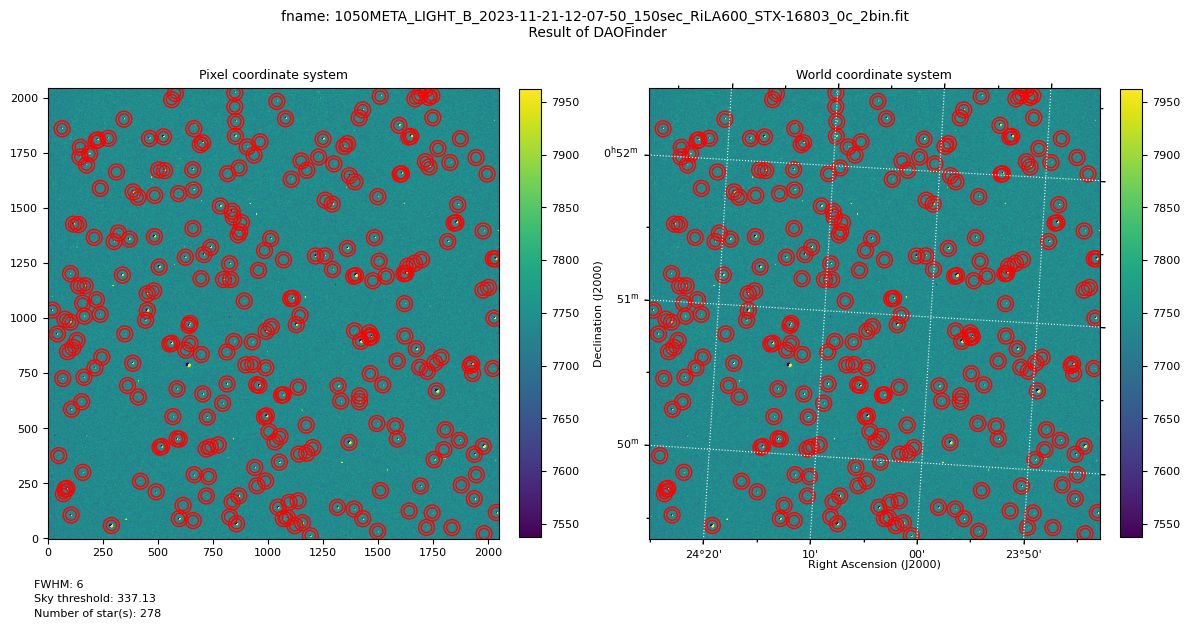

In [37]:
pos = np.transpose((DAOfound['xcentroid'], DAOfound['ycentroid']))
apert = CAp(pos, r=R_AP)
annul = CAn(positions=pos, r_in= R_IN, r_out=R_OUT)

fig_set = plt.figure(figsize=val_figsize)

ax1 = plt.subplot2grid((1,2), (0,0),
                    fig=fig_set)
im1 = _astro_utilities.zimshow(ax1, hdul[0].data, 
                               )
ax1.set_title('Pixel coordinate system', fontsize=9)
ax1.tick_params(labelsize=8)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)
im2 = _astro_utilities.zimshow(ax2, hdul[0].data, )
ax2.set_title('World coordinate system', fontsize=9)
ax2.coords.grid(True, color='white', ls=':')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)', minpad=0.5, fontsize=8)
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)', minpad=0.4, fontsize=8)
ax2.coords['dec'].set_ticklabel_position('bl')
ax2.coords['ra'].set_major_formatter('hh:mm')
ax2.coords['dec'].set_major_formatter('dd:mm')
ax2.coords['ra'].display_minor_ticks(True)
ax2.coords['dec'].display_minor_ticks(True)
ax2.coords['ra'].set_minor_frequency(2)
ax2.coords['dec'].set_minor_frequency(2)
ax2.tick_params(labelsize=8)

annul.plot(ax1, color="r")
annul.plot(ax2, color="r")

cbar1 = plt.colorbar(im1, ax = ax1, fraction=val_fraction, pad=0.04)
cbar2 = plt.colorbar(im2, ax = ax2, fraction=val_fraction, pad=0.04, )
cbar1.ax.tick_params(labelsize=8)
cbar2.ax.tick_params(labelsize=8)

plt.suptitle(f"fname: {fpath.name}\n Result of DAOFinder", fontsize=10,)

ax1.annotate(f'FWHM: {FWHM}', fontsize=8,
    xy=(0, 0), xytext=(-10, -30), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

ax1.annotate(f'Sky threshold: {thresh:.02f}', fontsize=8,
    xy=(0, 0), xytext=(-10, -40), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

ax1.annotate(f'Number of star(s): {len(DAOfound)}', fontsize=8,
    xy=(0, 0), xytext=(-10, -50), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

plt.tight_layout()
plt.savefig(f"{DIFFPRESULTDIR/fpath.stem}_DAOStarfinder_fwhm_{FWHM}.png")

# plt.show()
# plt.close()

In [38]:
pos = np.transpose((DAOfound['xcentroid'], DAOfound['ycentroid']))
apert = CAp(pos, r=R_AP)
annul = CAn(positions=pos, r_in= R_IN, r_out=R_OUT)
pos

array([[1191.21795155,   12.32940303],
       [1980.29939174,   21.49630692],
       [1496.96783948,   32.32977727],
       [1834.22504457,   49.23387134],
       [1718.8926911 ,   49.99037356],
       [1121.27951277,   58.05320348],
       [ 288.03736226,   59.00314618],
       [ 856.18582216,   66.72849192],
       [1155.36432563,   71.51545397],
       [ 659.42414886,   81.14600922],
       [ 596.45616518,   90.2792429 ],
       [1068.87748798,   90.13649416],
       [1429.71005075,   89.91781791],
       [1087.85699434,   93.38721691],
       [ 825.38947053,   98.49332512],
       [ 104.93630402,  106.27408214],
       [1744.44541405,  115.53907588],
       [2036.00474556,  117.76146008],
       [1640.15896747,  124.76754041],
       [1390.80452599,  133.41920495],
       [1044.43414232,  141.51085966],
       [1314.33882331,  141.2592048 ],
       [ 613.56893948,  150.2936895 ],
       [1094.78215101,  163.85237254],
       [ 836.30132004,  166.04359078],
       [1135.97755057,  1

# PS1과 DAOfound 목록 비교

In [39]:
apphot_result = apphot(hdul[0].data, apert, method='center')
print(type(apphot_result))
# df_apphot = pd.DataFrame()
# apphot_result
df_apphot = apphot_result.to_pandas()
print(type(df_apphot))
df_apphot

<class 'astropy.table.table.QTable'>
<class 'pandas.core.frame.DataFrame'>


,id,xcenter,ycenter,aperture_sum
0,1,1191.217952,12.329403,1.987676e+06
1,2,1980.299392,21.496307,1.964261e+06
2,3,1496.967839,32.329777,1.977339e+06
3,4,1834.225045,49.233871,1.974388e+06
4,5,1718.892691,49.990374,1.937353e+06
...,...,...,...,...
273,274,1687.859401,2010.925065,1.958826e+06
274,275,1743.154782,2010.429789,1.974837e+06
275,276,578.820408,2020.756419,1.975170e+06
276,277,848.641623,2023.432430,1.975931e+06


In [40]:
# cutsizes = 49
# for idx, row in df_apphot.iterrows():
#     #1. cut asteroia area
#     #print(idx)
#     try :

#         cut_hdu = Cutout2D(
#                     data = hdul[0].data,
#                     position = ((row['xcenter'],row['ycenter'])),
#                     size=(cutsizes, cutsizes) #cut ccd
#                     )
#         avg, med, std = sigma_clipped_stats(cut_hdu.data)  # by default, 3-sigma 5-iteration.

#         fig_set = plt.figure(figsize=(8, 5.5))
        
#         ax11 = plt.subplot2grid((2, 2), (0,0),
#                     fig=fig_set)
#         #im11 = _astro_utilities.zimshow(ax11, cut_hdu.data)
#         im11 = ax11.imshow(cut_hdu.data,
#                         origin="lower")

#         ax11.plot(round(cutsizes/2), round(cutsizes/2), 'rx')
#         ax11.set_ylabel('pixels')
#         ax11.grid(ls=':')
#         ax11.set_title(f'Star area image', fontsize=9)
#         ax11.annotate(   f"mean: {np.mean(cut_hdu.data):.01f}, std: {np.std(cut_hdu.data):.01f} \nmax: {np.max(cut_hdu.data):.01f}, min: {np.min(cut_hdu.data):.01f} \nNumber of Pixel: {np.shape(cut_hdu.data)[0]:.0f}x{np.shape(cut_hdu.data)[1]:.0f}",
#             xy=(0, 0), xytext=(0.1, -0.20),
#             xycoords='axes fraction',
#             va='top', ha='left',
#             fontsize=8)
#         plt.colorbar(im11,
#                     ax=ax11,
#                     label="ADU",
#                     fraction=0.0455, pad=0.04)
#         #print("Image size is: ", cut_hdu.data.shape)

#         #2. Get center dx, dy
#         thresh_3sig = med + 3 * std
#         mask_3sig = (cut_hdu.data < thresh_3sig)
#         center = centroid_com(
#                     data = cut_hdu.data,
#                     mask = mask_3sig
#                     )

#         centerdx = center[0] - ((cutsizes+1)/2)
#         centerdy = center[1] - ((cutsizes+1)/2)
#         # print("type(center):", type(center))
#         # print("center:", center)
#         # print("center dx, dy:", centerdx, centerdy)

#         ax12 = plt.subplot2grid((2,2), (0,1),
#                     fig=fig_set)
#         ax12.grid(ls=':')
#         ax12.set_title(f'The new center of Star', fontsize=9)
#         im12 = ax12.imshow(mask_3sig.astype(int),
#             origin="lower")
#         im12 = ax12.imshow(cut_hdu.data,
#                 alpha=0.4,
#                 origin="lower")
#         ax12.plot(*center, 'rx')
#         ax12.annotate(f"center: {center[0]:.02f}, {center[1]:.02f}\ncenter dx, dy: {centerdx:.02f}, {centerdy:.02f}",
#                 xy=(0, 0), xytext=(0.01, -0.20),
#                 xycoords='axes fraction',
#                 va='top', ha='left',
#                 fontsize=8)
        
#         ax11.annotate(f"star ID {idx}: ",
#                 xy=(1, 0), xytext=(-0.1, 1.33),
#                 xycoords='axes fraction',
#                 va='top', ha='left',
#                 fontsize=8)
        
#         plt.colorbar(im12,
#                     ax=ax12,
#                     label="ADU",
#                     fraction=0.0455, pad=0.04)
#         plt.suptitle(f"{fpath.name}", 
#                     fontsize=9)
        
#         plt.tight_layout()
#         # plt.savefig(f"{DIFFPRESULTDIR/fpath.stem}_Star_{idx:03d}.png")
#         # plt.show()
#         # plt.close()
#     except : 
#         continue

# 기기등급 구하기

In [41]:
ap_area  = apert.area
ap_area

# since our `annul` has many elements,
mask_apert = (apert.to_mask(method='center'))
mask_annul = (annul.to_mask(method='center'))

mag_ann  = np.zeros(len(apphot_result))
merr_ann = np.zeros(len(apphot_result))

# 구경측광 하기

In [42]:
for i in range(len(apphot_result)):
    annul_weighted = mask_annul[i].multiply(hdul[0].data)
    sky_non0   = np.nonzero(annul_weighted)
    sky_pixel  = annul_weighted[sky_non0]
    
    msky, sky_std, nsky, nrej = _astro_utilities.sky_fit(sky_pixel, method='mode', 
                                                        mode_option='sex')

    flux_star = apphot_result['aperture_sum'][i] - msky * ap_area  # total - sky

    flux_err  = np.sqrt(apphot_result['aperture_sum'][i] * gain    # Poissonian (star + sky)
                        + ap_area * rdnoise**2 # Gaussian
                        + (ap_area * (gain * sky_std))**2 / nsky )

    mag_ann[i], merr_ann[i] = mag_inst(flux_star, flux_err)
    df_apphot.at[i, 'msky'] = msky
    df_apphot.at[i, 'sky_std'] = sky_std
    df_apphot.at[i, 'nsky'] = nsky
    df_apphot.at[i, 'nrej'] = nrej
    df_apphot.at[i, 'flux_star'] = flux_star
    df_apphot.at[i, 'flux_err'] = flux_err
    df_apphot.at[i, 'mag_ann'] = mag_ann[i]
    df_apphot.at[i, 'merr_ann'] = merr_ann[i]

# sky = wcs.pixel_to_world(df_apphot['xcenter'], df_apphot['ycenter'])
# sky
# # df_apphot.to_csv(f"{INSTRESULTDIR}/{fpath.stem}_m_inst.csv")
# df_apphot

/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_335886/2869360460.py:3: RuntimeWarning: invalid value encountered in log10
  m_inst = -2.5 * np.log10(flux)
/tmp/ipykernel_3

In [43]:
df_apphot['filename'] = fpath.stem
df_apphot['t_start'] = t_start
df_apphot['t_expos'] = t_expos
df_apphot['t_middle'] = t_middle
df_apphot['filter'] = flt
df_apphot["zeropt_med"] = zeropt_med
df_apphot["zeropt_avg"] = zeropt_avg
df_apphot["e_zeropt"] = dzeropt

df_apphot[f"{flt}_magnitude"] = df_apphot["mag_ann"] - df_apphot["zeropt_med"]


In [44]:
#%%
sky_coord = wcs.pixel_to_world(df_apphot['xcenter'], df_apphot['ycenter'])
sky_coord
print(type(sky_coord))

# df_apphot["RA2000"] = sky_coord.ra
# df_apphot["RA2000"]
df_RADEC = pd.DataFrame({"RAJ2000": sky_coord.ra.degree, "DEJ2000": sky_coord.dec.degree})
# df_RADEC
#type(df_RADEC["RA2000"][0])
df_apphot = pd.concat([df_apphot, df_RADEC], axis=1,)

df_apphot.to_csv(f"{DIFFPRESULTDIR}/{fpath.stem}_result_photometry.csv")

<class 'astropy.coordinates.sky_coordinate.SkyCoord'>


In [45]:
df_apphot_sub = df_apphot.dropna()
df_apphot_sub

,id,xcenter,ycenter,aperture_sum,msky,sky_std,nsky,nrej,flux_star,flux_err,...,t_start,t_expos,t_middle,filter,zeropt_med,zeropt_avg,e_zeropt,B_magnitude,RAJ2000,DEJ2000
0,1,1191.217952,12.329403,1.987676e+06,7737.882430,66.821856,1437.0,12.0,18624.793274,1693.957659,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,13.758770,12.374652,24.009022
2,3,1496.967839,32.329777,1.977339e+06,7739.041134,68.191956,2184.0,14.0,7993.340360,1659.581452,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,14.677178,12.389566,23.904289
3,4,1834.225045,49.233871,1.974388e+06,7745.628358,69.837749,2253.0,12.0,3365.677697,1659.573034,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,15.616318,12.403964,23.788651
6,7,288.037362,59.003146,2.277204e+06,7743.832607,66.224675,2242.0,18.0,306638.578580,1765.493441,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,10.717432,12.369793,24.320812
7,8,856.185822,66.728492,2.130829e+06,7741.511011,68.127233,2251.0,10.0,160854.703545,1715.259278,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,11.417914,12.386852,24.125508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,272,1728.715949,2002.480001,1.974064e+06,7739.196652,68.253428,2241.0,19.0,4678.202012,1656.739371,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,15.258801,13.136069,23.865734
272,273,1508.474415,2008.082241,1.976966e+06,7736.915440,67.789928,2250.0,16.0,8161.070786,1656.706346,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,14.654631,13.133681,23.941762
274,275,1743.154782,2010.429789,1.974837e+06,7736.510577,68.835721,2253.0,10.0,6134.858499,1657.803166,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,14.964487,13.139368,23.860913
275,276,578.820408,2020.756419,1.975170e+06,7735.427061,68.317003,1933.0,24.0,6743.318681,1667.708944,...,2023-11-21T12:07:50.297,150.0,2023-11-21T12:09:05.297,B,-24.433999,-24.753166,0.043067,14.861815,13.118993,24.262505


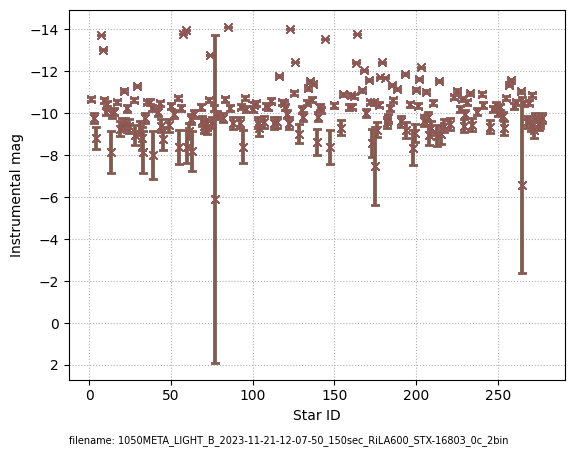

In [46]:
fig, ax = plt.subplots()

for idx, row in df_apphot_sub.iterrows():

    ax.errorbar(df_apphot_sub["id"], 
                df_apphot_sub["mag_ann"], yerr=df_apphot_sub["merr_ann"],
                marker='x',
                ls='none',
                #ms=10,
                capsize=3)

ax.invert_yaxis()
# ax.set_ylim(ymin=-20, ymax=0)

ax.annotate(f'filename: {fpath.stem}', fontsize=7,
    xy=(0, 0), xytext=(0, -40), va='top', ha='left',
    xycoords='axes fraction', textcoords='offset points')

plt.xlabel('Star ID')
plt.ylabel('Instrumental mag')
plt.grid(ls=':')

plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_m_inst_chart.png")
# plt.show()
# plt.close()

# 구경 측광 자료 표준화


In [47]:
df_apphot_sub.columns

Index(['id', 'xcenter', 'ycenter', 'aperture_sum', 'msky', 'sky_std', 'nsky',
       'nrej', 'flux_star', 'flux_err', 'mag_ann', 'merr_ann', 'filename',
       't_start', 't_expos', 't_middle', 'filter', 'zeropt_med', 'zeropt_avg',
       'e_zeropt', 'B_magnitude', 'RAJ2000', 'DEJ2000'],
      dtype='object')

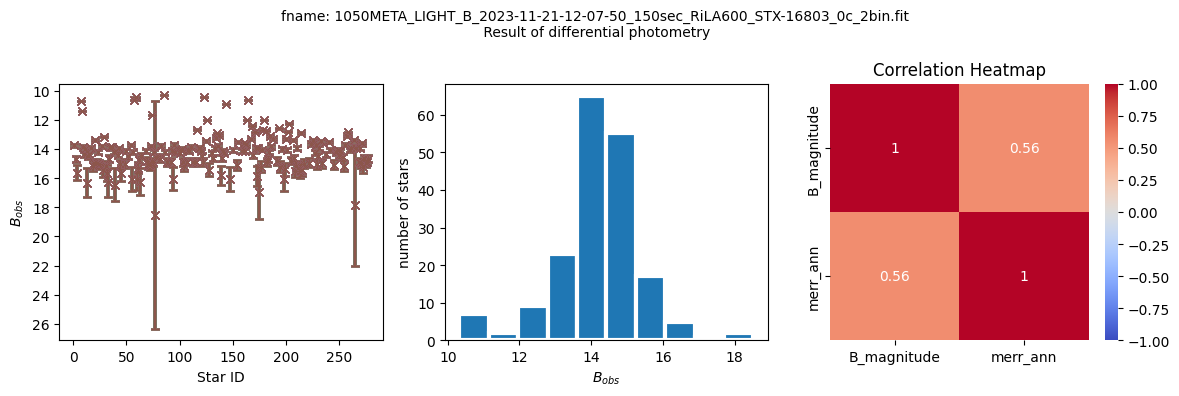

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=False, sharey=False, gridspec_kw=None)

for idx, row in df_apphot_sub.iterrows():

    axs[0].errorbar(df_apphot_sub["id"], 
                df_apphot_sub[f"{flt}_magnitude"], yerr=df_apphot_sub["merr_ann"],
                marker='x',
                ls='none',
                #ms=10,
                capsize=3)

axs[0].invert_yaxis()

style = {'edgecolor': 'white', 'linewidth': 3}
axs[1].hist(df_apphot_sub[f"{flt}_magnitude"], 
            **style)

data =  df_apphot_sub[[f"{flt}_magnitude", "merr_ann"]]
# 상관관계 계산
corr = data.corr()

# 히트맵 그리기
axs[2] = sns.heatmap(corr, annot=True, cmap='coolwarm', 
                     vmin=-1, vmax=1, center=0)
    
axs[0].set(
    xlabel='Star ID',
    ylabel=f"${{{flt}}}_{{obs}}$"
)
axs[1].set(
    xlabel=f"${{{flt}}}_{{obs}}$",
    ylabel="number of stars"
)

axs[2].set(
    title = 'Correlation Heatmap',
)

plt.suptitle(f"fname: {fpath.name}\n Result of differential photometry", fontsize=10,)

plt.tight_layout()
plt.savefig(f"{DIFFPRESULTDIR}/{fpath.stem}_Result_of_differential_photometry.png")

# plt.show()
# plt.close()